<a href="https://colab.research.google.com/github/mmbc560/GUIA2/blob/main/Prueba_Logyca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1_Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import files

uploaded = files.upload()

Saving DATA_LOGYCA.xlsx to DATA_LOGYCA.xlsx


In [4]:
excel = pd.ExcelFile("DATA_LOGYCA.xlsx")

excel.sheet_names

['Hoja1']

In [5]:
df = pd.read_excel(
    "DATA_LOGYCA.xlsx",
    sheet_name="Hoja1"
)

df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,DATOS DE LA OPERACIÓN LOGISTICA DE EMPRESAS DEDICADAS AL TRANSPORTE,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EMPRESA,ID DE VIAJE,FECHA DE VIAJE,PLACA,TIPO DE VEHICULO,MODELO,CARGA TRANSPORTADA(kg),CAPACIDAD TRANSPORTADA (kg),ORIGEN,DESTINO,DISTANCIA,TIPO DE COMBUSTIBLE,RENDIMIENTO DEL COMBUSTIBLE(Km/Gal)
2,Empresa 1,1,2024-01-02 00:00:00,SZQ663,SC Sencillo,NaN,1016,6,BOGOTÁ,CALI,NaN,Diesel,20.796275
3,Empresa 1,2,2024-01-02 00:00:00,SNM494,SC Sencillo,NaN,3126,43,CALI,BOGOTÁ,NaN,Diesel,16.982485
4,Empresa 1,3,2024-01-02 00:00:00,SZQ460,SC Sencillo,NaN,1906,47,SIBERIA,MEDELLÍN,NaN,Diesel,17.909001


In [7]:
df = pd.read_excel(
    "DATA_LOGYCA.xlsx",
    sheet_name="Hoja1",
    header=2
)


In [8]:
df = df.dropna(axis=1, how="all")

In [9]:
df = df.reset_index(drop=True)

In [10]:
df.head()

,EMPRESA,ID DE VIAJE,FECHA DE VIAJE,PLACA,TIPO DE VEHICULO,MODELO,CARGA TRANSPORTADA(kg),CAPACIDAD TRANSPORTADA (kg),ORIGEN,DESTINO,DISTANCIA,TIPO DE COMBUSTIBLE,RENDIMIENTO DEL COMBUSTIBLE(Km/Gal)
0,Empresa 1,1.0,2024-01-02,SZQ663,SC Sencillo,NaN,1016.0,6.0,BOGOTÁ,CALI,NaN,Diesel,20.796275
1,Empresa 1,2.0,2024-01-02,SNM494,SC Sencillo,NaN,3126.0,43.0,CALI,BOGOTÁ,NaN,Diesel,16.982485
2,Empresa 1,3.0,2024-01-02,SZQ460,SC Sencillo,NaN,1906.0,47.0,SIBERIA,MEDELLÍN,NaN,Diesel,17.909001
3,Empresa 1,4.0,2024-01-02,WEO968,SC Sencillo,NaN,1141.0,25.0,SIBERIA,SIBERIA,NaN,Diesel,17.000000
4,Empresa 1,5.0,2024-01-02,FUY640,SC Sencillo,NaN,4459.0,257.0,PEREIRA,BOGOTÁ,NaN,Diesel,17.000000


In [11]:
print("Dataset dimensions:")
print(df.shape)

print("\n")

print("Data types and missing values:")
df.info()

Dataset dimensions:
(50448, 13)


Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50448 entries, 0 to 50447
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   EMPRESA                              3702 non-null   object        
 1   ID DE VIAJE                          18710 non-null  float64       
 2   FECHA DE VIAJE                       3702 non-null   datetime64[ns]
 3   PLACA                                3699 non-null   object        
 4   TIPO DE VEHICULO                     3696 non-null   object        
 5   MODELO                               1679 non-null   float64       
 6   CARGA TRANSPORTADA(kg)               3702 non-null   float64       
 7   CAPACIDAD TRANSPORTADA (kg)          3702 non-null   float64       
 8   ORIGEN                               3699 non-null   object        
 9   DESTINO           

In [12]:
df = df[df["EMPRESA"].notna()]


In [13]:
df = df.reset_index(drop=True)

In [14]:
print(df.shape)

(3702, 13)


In [15]:
print("Number of companies:", df["EMPRESA"].nunique())

print("\nVehicle types:")
print(df["TIPO DE VEHICULO"].value_counts())

print("\nFuel types:")
print(df["TIPO DE COMBUSTIBLE"].value_counts())

Number of companies: 3

Vehicle types:
TIPO DE VEHICULO
SC Sencillo                           952
CM Camioneta                          721
Turbo Furgon                          603
TB Turbo                              347
Tractomula Plancha 3 ejes             257
Sencillo Plancha                      241
Camioneta Furgón                      142
Turbo Extra Dimensionado              139
Mini Mula Porta Contenedor 2 ejes     114
Sencillo Furgon                        77
Mini Mula Furgon 2 ejes                43
Mini Mula Plancha 2 ejes               18
Tractomula Porta Contenedor 2 ejes     16
Tractomula Furgon 3 ejes               14
Mini Mula Porta Contenedor 3 ejes       5
Mini Mula Furgon 3 Ejes                 4
Tractomula Porta Contenedor 3 ejes      2
Mini Mula Plancha 3 ejes                1
Name: count, dtype: int64

Fuel types:
TIPO DE COMBUSTIBLE
Diesel               1954
Gasolina               53
Energía eléctrica      16
Name: count, dtype: int64


In [16]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": round(df.isnull().mean() * 100, 2)
})

missing = missing.sort_values("Percentage (%)", ascending=False)

missing

,Missing Values,Percentage (%)
MODELO,2023,54.65
TIPO DE COMBUSTIBLE,1679,45.35
DISTANCIA,1004,27.12
TIPO DE VEHICULO,6,0.16
PLACA,3,0.08
DESTINO,3,0.08
ORIGEN,3,0.08
EMPRESA,0,0.00
FECHA DE VIAJE,0,0.00
ID DE VIAJE,0,0.00


In [17]:
#KPI_1 Trips
company_trips = (
    df["EMPRESA"]
    .value_counts()
    .reset_index()
)

company_trips.columns = ["Company", "Trips"]

company_trips["Percentage"] = round(
    company_trips["Trips"] /
    company_trips["Trips"].sum() * 100,
    2
)

company_trips

,Company,Trips,Percentage
0,Empresa 3,1679,45.35
1,Empresa 2,1019,27.53
2,Empresa 1,1004,27.12


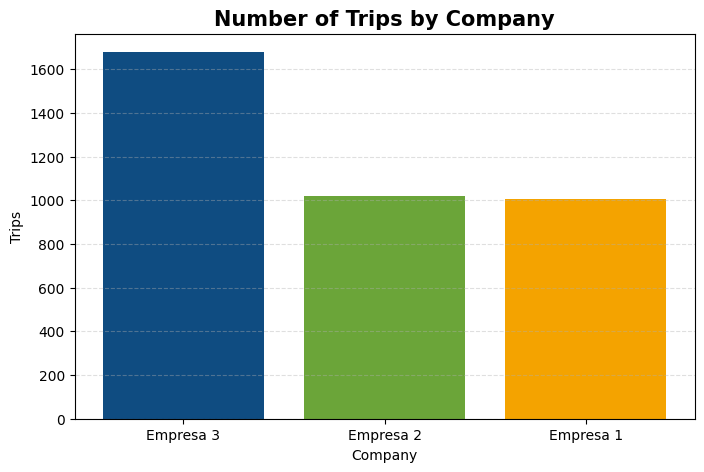

In [19]:
plt.figure(figsize=(8,5))

colors = ["#0F4C81", "#6BA539", "#F4A300"]

bars = plt.bar(
    company_trips["Company"],
    company_trips["Trips"],
    color=colors
)

plt.title("Number of Trips by Company", fontsize=15, fontweight="bold")
plt.xlabel("Company")
plt.ylabel("Trips")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

### Interpretation

The logistics operation is distributed across three companies.

Company 3 accounts for approximately 45% of all recorded trips, making it the dominant freight generator in the analyzed dataset.

Companies 1 and 2 contribute similar proportions, representing approximately 27% of the total trips each.

This distribution indicates that Company 3 should receive particular attention during the assessment of operational efficiency and potential decarbonization opportunities.


In [22]:
df[[
    "CARGA TRANSPORTADA(kg)",
    "CAPACIDAD TRANSPORTADA (kg)"
]].describe()

,CARGA TRANSPORTADA(kg),CAPACIDAD TRANSPORTADA (kg)
count,3702.000000,3702.000000
mean,2697.645327,3454.637707
std,4377.255516,6880.701761
min,0.000000,0.000000
25%,288.250000,15.000000
50%,933.000000,769.630000
75%,3360.750000,1603.885000
max,27994.000000,50588.000000


In [23]:
# KPI 2 - Load Factor (%)

df["LOAD_FACTOR (%)"] = (
    df["CARGA TRANSPORTADA(kg)"] /
    df["CAPACIDAD TRANSPORTADA (kg)"]
) * 100

df["LOAD_FACTOR (%)"].head()

,LOAD_FACTOR (%)
0,16933.333333
1,7269.767442
2,4055.319149
3,4564.000000
4,1735.019455


In [24]:
df["LOAD_FACTOR (%)"].describe()

,LOAD_FACTOR (%)
count,3698.000000
mean,29988.291558
std,83488.877020
min,2.480000
25%,48.599659
50%,74.627503
75%,2404.318182
max,447400.000000


In [25]:
df[[
    "CARGA TRANSPORTADA(kg)",
    "CAPACIDAD TRANSPORTADA (kg)"
]].head(20)

,CARGA TRANSPORTADA(kg),CAPACIDAD TRANSPORTADA (kg)
0,1016.0,6.0
1,3126.0,43.0
2,1906.0,47.0
3,1141.0,25.0
4,4459.0,257.0
5,1326.0,1.0
6,3335.0,1.0
7,2574.0,1.0
8,4070.0,2.0
9,3882.0,1.0


The variable Vehicle Capacity presents inconsistencies in the recorded units. Early observations include values such as 1, 2, 6 and 43, while other records contain capacities above 50,000. Therefore, the Load Factor indicator was not considered reliable for decision-making without prior validation of the measurement units.

## KPI 2. Fuel Efficiency Analysis

In [26]:
fuel_stats = df["RENDIMIENTO DEL COMBUSTIBLE(Km/Gal)"].describe()

fuel_stats

,RENDIMIENTO DEL COMBUSTIBLE(Km/Gal)
count,3702.000000
mean,16.468414
std,5.895086
min,1.758845
25%,14.940000
50%,15.200000
75%,18.224830
max,90.740000


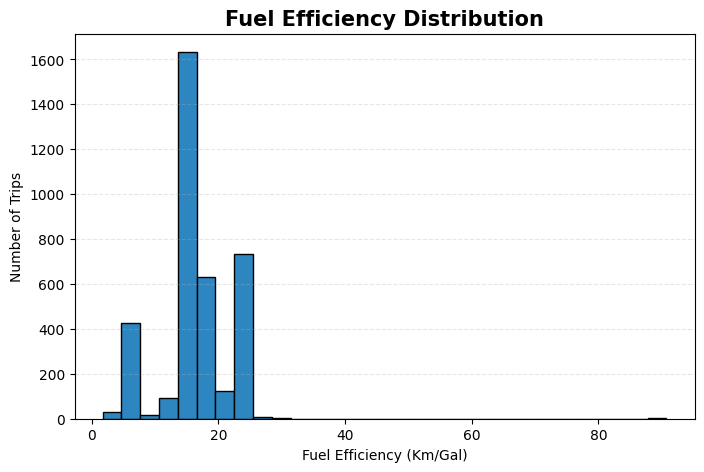

In [28]:
plt.figure(figsize=(8,5))

plt.hist(
    df["RENDIMIENTO DEL COMBUSTIBLE(Km/Gal)"],
    bins=30,
    color="#2E86C1",      # Azul
    edgecolor="black"
)

plt.title("Fuel Efficiency Distribution", fontsize=15, fontweight="bold")
plt.xlabel("Fuel Efficiency (Km/Gal)")
plt.ylabel("Number of Trips")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

Fuel efficiency varies across the analyzed trips, indicating differences in vehicle performance and operating conditions.

Lower fuel efficiency values may be associated with higher fuel consumption, representing potential opportunities for operational improvement and future decarbonization initiatives.

This indicator provides a reliable baseline for evaluating logistics efficiency because the variable contains complete information for all analyzed records.

## KPI 3. Fuel Type Distribution

In [29]:
fuel_summary = (
    df["TIPO DE COMBUSTIBLE"]
    .value_counts(dropna=False)
    .reset_index()
)

fuel_summary.columns = ["Fuel Type", "Trips"]

fuel_summary["Percentage"] = round(
    fuel_summary["Trips"] /
    fuel_summary["Trips"].sum() * 100,
    2
)

fuel_summary

,Fuel Type,Trips,Percentage
0,Diesel,1954,52.78
1,NaN,1679,45.35
2,Gasolina,53,1.43
3,Energía eléctrica,16,0.43


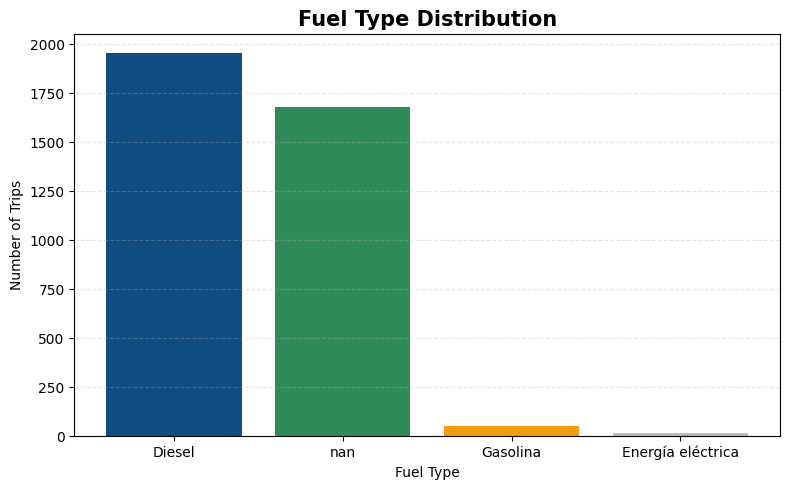

In [30]:
plt.figure(figsize=(8,5))

colors = ["#0F4C81", "#2E8B57", "#F39C12", "#BDBDBD"]

plt.bar(
    fuel_summary["Fuel Type"].astype(str),
    fuel_summary["Trips"],
    color=colors[:len(fuel_summary)]
)

plt.title("Fuel Type Distribution", fontsize=15, fontweight="bold")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Trips")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

In [31]:
df["TIPO DE COMBUSTIBLE"].value_counts(dropna=False)

,count
TIPO DE COMBUSTIBLE,
Diesel,1954
NaN,1679
Gasolina,53
Energía eléctrica,16


In [32]:
fuel_summary = (
    df["TIPO DE COMBUSTIBLE"]
    .dropna()
    .value_counts()
    .reset_index()
)

fuel_summary.columns = ["Fuel Type", "Trips"]

fuel_summary["Percentage"] = round(
    fuel_summary["Trips"] /
    fuel_summary["Trips"].sum() * 100,
    2
)

fuel_summary

,Fuel Type,Trips,Percentage
0,Diesel,1954,96.59
1,Gasolina,53,2.62
2,Energía eléctrica,16,0.79


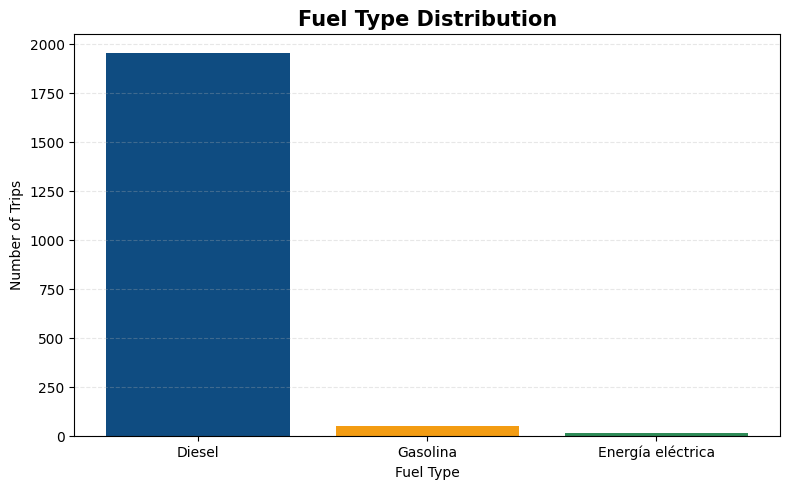

In [33]:
plt.figure(figsize=(8,5))

colors = ["#0F4C81", "#F39C12", "#2E8B57"]

plt.bar(
    fuel_summary["Fuel Type"],
    fuel_summary["Trips"],
    color=colors
)

plt.title(
    "Fuel Type Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Fuel Type")
plt.ylabel("Number of Trips")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

Among the records with available fuel information, diesel is the predominant fuel, accounting for approximately 97% of the fleet.

Gasoline and electric vehicles represent only a small fraction of the analyzed trips, indicating a limited adoption of lower-emission technologies.

These results suggest that improving diesel fleet efficiency and progressively incorporating cleaner technologies could significantly contribute to future decarbonization efforts.

It is important to note that some records do not contain fuel type information; therefore, this analysis considers only observations with valid data.

In [1]:
import matplotlib.pyplot as plt

# Filtrar registros con información válida de combustible
fuel_valid = df["TIPO DE COMBUSTIBLE"].dropna()

# Clasificar entre Diesel y otros combustibles
fuel_group = fuel_valid.apply(
    lambda x: "Diésel" if str(x).strip().lower() == "diesel" else "Otros combustibles"
)

fuel_counts = fuel_group.value_counts()

# Crear gráfico de dona
plt.figure(figsize=(6, 6))

wedges, texts, autotexts = plt.pie(
    fuel_counts.values,
    labels=fuel_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.38, "edgecolor": "white"},
    textprops={"fontsize": 12}
)

plt.title(
    "Distribución de viajes por tipo de combustible",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

In [2]:
import pandas as pd

df = pd.read_excel(
    "DATA_LOGYCA.xlsx",
    header=1
)

# Eliminar filas completamente vacías
df = df.dropna(how="all")

print(df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'DATA_LOGYCA.xlsx'